## 1. Carregamento e Inspeção Inicial

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais para um estilo mais profissional e acadêmico
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Carregar a base de modelagem
df = pd.read_csv('../data/processed/base_modelagem_brasil.csv', sep=';')


# Visualizando as primeiras linhas e as informações estruturais
display(df.head())
print(df.info())

,id,pesid,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,...,feridos_graves,mortos,ano,km_join,icc,icp,icm,cond_pavimento,cond_conservacao,cond_pista
0,571789.0,1269011,2024-01-01,segunda-feira,03:56:00,ES,101,38.0,CONCEICAO DA BARRA,Ultrapassagem Indevida,...,0,0,2024,38,NaN,NaN,NaN,NaN,NaN,NaN
1,571806.0,1269735,2024-01-01,segunda-feira,04:30:00,BA,116,578.0,BREJOES,Ingestão de álcool pelo condutor,...,0,0,2024,578,18.75,20.0,19.625,NaN,NaN,NaN
2,571818.0,1269075,2024-01-01,segunda-feira,06:30:00,SE,101,18.0,MALHADA DOS BOIS,Reação tardia ou ineficiente do condutor,...,1,0,2024,18,0.00,0.0,0.000,NaN,NaN,NaN
3,571838.0,1269159,2024-01-01,segunda-feira,05:00:00,MT,364,240.0,RONDONOPOLIS,Condutor deixou de manter distância do veículo...,...,0,0,2024,240,30.00,35.0,33.500,NaN,X,NaN
4,571910.0,1269450,2024-01-01,segunda-feira,15:45:00,BA,116,852.9,VITORIA DA CONQUISTA,Chuva,...,0,0,2024,853,30.00,42.5,38.750,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216734 entries, 0 to 216733
Data columns (total 38 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      216734 non-null  float64
 1   pesid                   216734 non-null  int64  
 2   data_inversa            216734 non-null  object 
 3   dia_semana              216734 non-null  object 
 4   horario                 216734 non-null  object 
 5   uf                      216734 non-null  object 
 6   br                      216734 non-null  int64  
 7   km                      216734 non-null  float64
 8   municipio               216734 non-null  object 
 9   causa_acidente          216734 non-null  object 
 10  tipo_acidente           216734 non-null  object 
 11  classificacao_acidente  216719 non-null  object 
 12  fase_dia                216734 non-null  object 
 13  sentido_via             216734 non-null  object 
 14  condicao_metereologi

## 2. Tratamento de Valores Nulos
Para variáveis numéricas, podemos preencher dados ausentes com a mediana (que é menos sensível a outliers do que a média). Para variáveis categóricas, podemos preencher com "Não Informado" ou a moda, dependendo da criticidade.

In [72]:
# 1. Identificando as 10 BRs com maior volume de registros
top_10_brs = df['br'].value_counts().nlargest(10).index
print(f"As 10 BRs com mais registros são: {list(top_10_brs)}\n")

# 2. Filtrando o dataset para conter apenas essas 10 BRs
df_top10_brs = df[df['br'].isin(top_10_brs)]

print(f"Quantidade total de registros nas Top 10 BRs: {len(df_top10_brs)}")

# 3. Calculando a quantidade e o percentual de valores nulos nesse subconjunto
nulos_qtd = df_top10_brs.isnull().sum()
nulos_pct = (nulos_qtd / len(df_top10_brs)) * 100

# 4. Criando um DataFrame consolidado para facilitar a visualização
df_nulos_top10 = pd.DataFrame({
    'Quantidade_Nulos': nulos_qtd,
    'Percentual_Nulos(%)': nulos_pct
}).sort_values(by='Quantidade_Nulos', ascending=False)

# 5. Exibindo apenas as colunas que apresentam valores nulos nas Top 10 BRs
colunas_com_nulos = df_nulos_top10[df_nulos_top10['Quantidade_Nulos'] > 0]

print("\nResumo de valores nulos nas Top 10 BRs:")
display(colunas_com_nulos)


As 10 BRs com mais registros são: [101, 116, 153, 364, 230, 316, 158, 10, 174, 242]

Quantidade total de registros nas Top 10 BRs: 216734

Resumo de valores nulos nas Top 10 BRs:


,Quantidade_Nulos,Percentual_Nulos(%)
cond_pista,216734,100.000000
cond_pavimento,216734,100.000000
cond_conservacao,216259,99.780837
icp,118746,54.788819
icc,118746,54.788819
icm,118354,54.607953
tipo_envolvido,18517,8.543653
sexo,18517,8.543653
estado_fisico,18517,8.543653
tipo_veiculo,7166,3.306357


### 2.1. Remoção de colunas

In [73]:
# Retirando as colunas especificadas do dataset das Top 10 BRs
colunas_para_remover = ['cond_pavimento', 'cond_pista', 'cond_conservacao']

# O parâmetro axis=1 indica que estamos removendo colunas (não linhas)
# O uso do 'errors="ignore"' evita que o código quebre caso as colunas já tenham sido removidas rodando a célula duas vezes
df_top10_brs = df_top10_brs.drop(columns=colunas_para_remover, errors='ignore')

print("Colunas removidas com sucesso.")

Colunas removidas com sucesso.


### 2.2. Preenchimento de dados categóricos

In [74]:
# Identificando automaticamente todas as colunas que são de texto (object)
colunas_categoricas = df_top10_brs.select_dtypes(include=['object']).columns

# Preenchendo os valores nulos (NaN) dessas colunas com a string "Não Informado"
df_top10_brs[colunas_categoricas] = df_top10_brs[colunas_categoricas].fillna('Não Informado')

print(f"Valores nulos preenchidos nas colunas categóricas: {list(colunas_categoricas)}")

Valores nulos preenchidos nas colunas categóricas: ['data_inversa', 'dia_semana', 'horario', 'uf', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'tipo_veiculo', 'marca', 'tipo_envolvido', 'estado_fisico', 'sexo']


### 2.3. Preenchimento de icp, icc e icm (Interpolação)

In [75]:
# 1. Ordenando espacialmente para garantir que as linhas adjacentes são geograficamente próximas
df_top10_brs = df_top10_brs.sort_values(by=['br', 'km_join', 'data_inversa'])

# 2. Agora sim, as colunas a interpolar
colunas_indices = ['icc', 'icp', 'icm']

# 3. Aplicando a interpolação linear (agora ela vai olhar para os KMs vizinhos da mesma BR!)
df_top10_brs[colunas_indices] = df_top10_brs[colunas_indices].interpolate(method='linear')

# 4. Preenchendo as pontas soltas
df_top10_brs[colunas_indices] = df_top10_brs[colunas_indices].bfill().ffill()

print("Interpolação espacialmente coerente concluída com sucesso!")

Interpolação espacialmente coerente concluída com sucesso!


### 3. Tratamento valores duplicados 

In [76]:
duplicados_antes = df_top10_brs.duplicated().sum()
df_top10_brs = df_top10_brs.drop_duplicates()
print(f"Foram encontrados e removidos {duplicados_antes} registros duplicados.")

# Criando a Variável Alvo (Target): Acidente Grave ou Fatal
# Se houver mortos OU feridos graves, o acidente recebe 1 (Grave/Fatal). Caso contrário, 0.
df_top10_brs['acidente_grave_ou_fatal'] = np.where(
    (df_top10_brs['mortos'] > 0) | (df_top10_brs['feridos_graves'] > 0), 1, 0
)

# Verificando o novo balanceamento do nosso alvo
print("\nDistribuição do Novo Alvo (Acidente Grave ou Fatal?):")
print(df_top10_brs['acidente_grave_ou_fatal'].value_counts(normalize=True) * 100)

# AGORA SIM: Removemos as colunas de vítimas para o modelo não trapacear (Data Leakage)
colunas_vazamento = ['mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'estado_fisico']
df_top10_brs = df_top10_brs.drop(columns=colunas_vazamento, errors='ignore')

print("\nColunas de contagem de vítimas removidas com sucesso para evitar vazamento de dados.")

Foram encontrados e removidos 0 registros duplicados.

Distribuição do Novo Alvo (Acidente Grave ou Fatal?):
acidente_grave_ou_fatal
0    87.022341
1    12.977659
Name: proportion, dtype: float64

Colunas de contagem de vítimas removidas com sucesso para evitar vazamento de dados.


## 4. Análise de Outliers
Neste bloco, utilizamos o método estatístico do **Intervalo Interquartil (IQR)** para identificar e tratar valores discrepantes nos índices da via (`icc`, `icp`, `icm`). 



--- ANÁLISE DE OUTLIERS (ANTES DO TRATAMENTO) ---
[ICC]
  -> Extremos Reais da Base: Mín = 0.00 | Máx = 100.00
  -> Limites Seguros (IQR) : Inf = -23.12 | Sup = 51.88
  -> Outliers a Esmagar   : 5203 registros

[ICP]
  -> Extremos Reais da Base: Mín = 0.00 | Máx = 90.00
  -> Limites Seguros (IQR) : Inf = -27.59 | Sup = 45.98
  -> Outliers a Esmagar   : 13205 registros

[ICM]
  -> Extremos Reais da Base: Mín = 0.00 | Máx = 86.00
  -> Limites Seguros (IQR) : Inf = -17.62 | Sup = 40.88
  -> Outliers a Esmagar   : 11909 registros



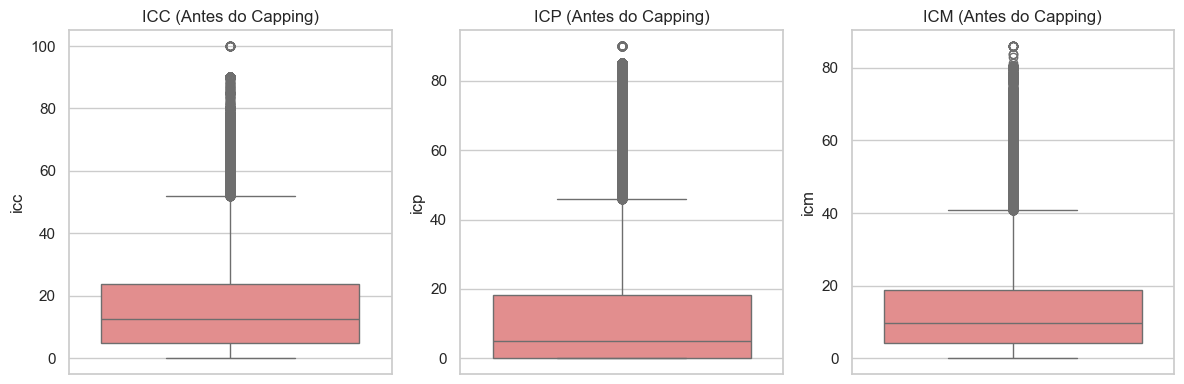

In [77]:
# ==========================================
# 4.A. DETECÇÃO E VISUALIZAÇÃO DOS OUTLIERS
# ==========================================

# 1. Definindo as colunas numéricas contínuas para análise
colunas_indices = ['icc', 'icp', 'icm']

print("--- ANÁLISE DE OUTLIERS (ANTES DO TRATAMENTO) ---")

# 2. Loop para calcular limites, exibir extremos e contar outliers sem alterar os dados
for coluna in colunas_indices:
    # Calculando os limites matemáticos
    Q1 = df_top10_brs[coluna].quantile(0.25)
    Q3 = df_top10_brs[coluna].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Extraindo os valores extremos reais presentes na base
    valor_min = df_top10_brs[coluna].min()
    valor_max = df_top10_brs[coluna].max()
    
    # Contabilizando quantos outliers existem
    outliers_mask = (df_top10_brs[coluna] > limite_superior) | (df_top10_brs[coluna] < limite_inferior)
    qtd_outliers = len(df_top10_brs[outliers_mask])
    
    # Exibindo o mini-relatório por variável
    print(f"[{coluna.upper()}]")
    print(f"  -> Extremos Reais da Base: Mín = {valor_min:.2f} | Máx = {valor_max:.2f}")
    print(f"  -> Limites Seguros (IQR) : Inf = {limite_inferior:.2f} | Sup = {limite_superior:.2f}")
    print(f"  -> Outliers a Esmagar   : {qtd_outliers} registros\n")

# 3. Visualizando a distribuição original (com a presença dos pontos extremos)
plt.figure(figsize=(12, 4))
for i, col in enumerate(colunas_indices, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df_top10_brs[col], color='lightcoral')
    plt.title(f'{col.upper()} (Antes do Capping)')

plt.tight_layout()
plt.show()

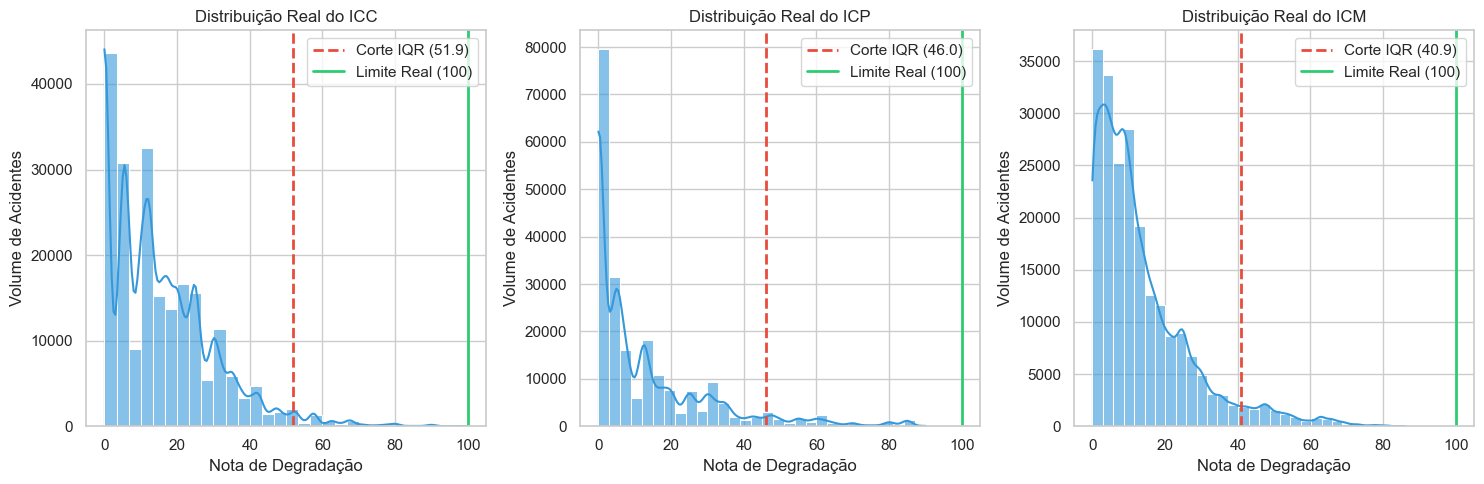

In [78]:
colunas_indices = ['icc', 'icp', 'icm']

plt.figure(figsize=(15, 5))

for i, coluna in enumerate(colunas_indices, 1):
    plt.subplot(1, 3, i)
    
    # Calculando o limite superior do IQR apenas para o gráfico
    Q1 = df_top10_brs[coluna].quantile(0.25)
    Q3 = df_top10_brs[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    
    # Plotando o Histograma de Densidade
    sns.histplot(data=df_top10_brs, x=coluna, bins=30, kde=True, color='#3498db', alpha=0.6)
    
    # Linha Vermelha: Onde o IQR faria o corte (Capping)
    plt.axvline(x=limite_superior, color='#e74c3c', linestyle='--', linewidth=2, 
                label=f'Corte IQR ({limite_superior:.1f})')
    
    # Linha Verde: O limite máximo real do negócio
    plt.axvline(x=100, color='#2ecc71', linestyle='-', linewidth=2, 
                label='Limite Real (100)')
    
    plt.title(f'Distribuição Real do {coluna.upper()}')
    plt.xlabel('Nota de Degradação')
    plt.ylabel('Volume de Acidentes')
    plt.legend()

plt.tight_layout()
plt.show()

In [79]:
import os

# 1. Definindo o caminho da pasta e o nome do arquivo dedicado à AED
pasta_destino = '../data/processed/data_model'
nome_arquivo = 'dados_aed.csv'

# 2. Garantindo que a estrutura de pastas exista
os.makedirs(pasta_destino, exist_ok=True)

# 3. Juntando a pasta com o nome do arquivo para ter o caminho completo
caminho_completo = os.path.join(pasta_destino, nome_arquivo)

# 4. Verificando se o documento já existe para deletá-lo antes de salvar o novo
if os.path.exists(caminho_completo):
    os.remove(caminho_completo)
    print(f"⚠️ Arquivo anterior '{nome_arquivo}' encontrado e deletado.")
else:
    print(f"✨ Nenhum arquivo anterior encontrado. Criando um novo arquivo de AED.")

# 5. Criando uma cópia limpa sem os identificadores que não servem para os gráficos
colunas_inuteis = ['id', 'pesid', 'id_veiculo']
df_exportar = df_top10_brs.drop(columns=colunas_inuteis, errors='ignore')

# 6. Exportando o dataset que agora se chama df_exportar
df_exportar.to_csv(caminho_completo, index=False, sep=';')

print(f"✅ Sucesso! Dataset puro para a AED exportado em: '{caminho_completo}'")
print("O Notebook de Normalização pode ser encerrado com segurança.")

⚠️ Arquivo anterior 'dados_aed.csv' encontrado e deletado.
✅ Sucesso! Dataset puro para a AED exportado em: '../data/processed/data_model\dados_aed.csv'
O Notebook de Normalização pode ser encerrado com segurança.
